# 01 — Focused EDA: IBM Telco Customer Churn

Scope is deliberately narrow (see blueprint §8.3): the portfolio value is the *system*, not 40 plots.
This notebook reads the **raw, immutable** CSV and never writes to it.

**Framing:** the dataset is a cross-sectional snapshot. It supports churn *risk classification*,
not time-bound forecasting ("will churn in the next 30 days").

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.config import RAW_DATA_PATH
from src.data.validate import to_numeric_charges, validate_raw

raw = pd.read_csv(ROOT / RAW_DATA_PATH.relative_to(ROOT))
summary = validate_raw(raw)
summary

{'rows': 7043,
 'columns': 21,
 'churn_rate': 0.2653698707936959,
 'blank_total_charges': 11}

## 1. Target rate
Roughly one in four customers churned — imbalanced enough that **PR-AUC** should be the headline metric, with ROC-AUC as a complement.

In [2]:
raw["Churn"].value_counts().to_frame("customers").assign(share=lambda d: (d.customers / d.customers.sum()).round(3))

,customers,share
Churn,,
No,5174,0.735
Yes,1869,0.265


## 2. Data quality: duplicates and blank `TotalCharges`

In [3]:
df = raw.copy()
df["TotalCharges"] = to_numeric_charges(df["TotalCharges"])
print("duplicate customerID:", df["customerID"].duplicated().sum())
blank = df[df["TotalCharges"].isna()]
print("blank TotalCharges:", len(blank))
blank[["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]]

duplicate customerID: 0
blank TotalCharges: 11


,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


All blank `TotalCharges` rows have **tenure = 0**: brand-new customers who have not been billed yet.
They are kept and imputed inside the sklearn pipeline (median), and the API accepts `TotalCharges: null`
for the same case. Dropping them would silently remove new customers from the population.

In [4]:
assert (blank["tenure"] == 0).all()

## 3. Numeric distributions by churn

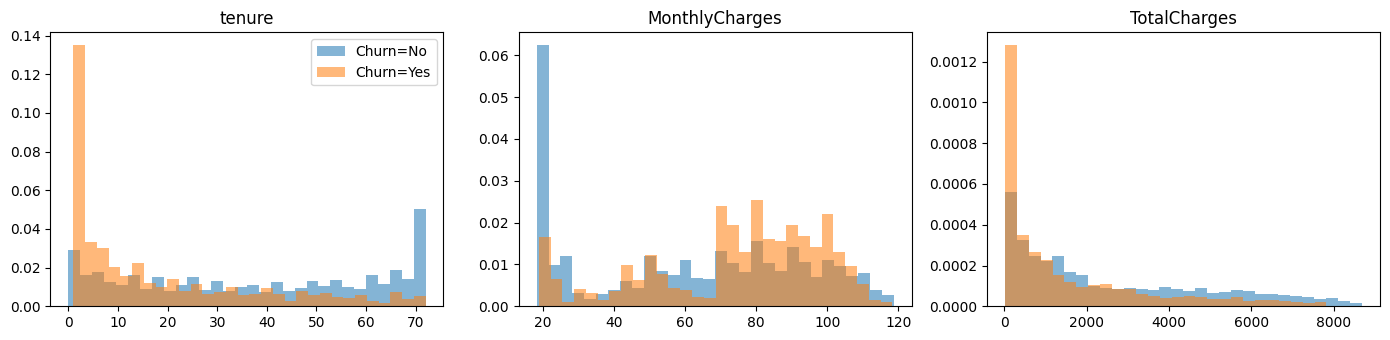

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    for label, part in df.groupby("Churn"):
        ax.hist(part[col].dropna(), bins=30, alpha=0.55, density=True, label=f"Churn={label}")
    ax.set_title(col)
axes[0].legend()
plt.tight_layout()

Churners are concentrated at **low tenure** and **higher monthly charges**; `TotalCharges` largely mirrors tenure × price.

## 4. Churn rate by key account attributes

In [6]:
df["churn_flag"] = (df["Churn"] == "Yes").astype(int)
tables = {}
for col in ["Contract", "InternetService", "PaymentMethod", "TechSupport"]:
    tables[col] = (df.groupby(col)["churn_flag"].agg(customers="size", churn_rate="mean")
                   .sort_values("churn_rate", ascending=False).round(3))
    display(tables[col])

,customers,churn_rate
Contract,,
Month-to-month,3875,0.427
One year,1473,0.113
Two year,1695,0.028


,customers,churn_rate
InternetService,,
Fiber optic,3096,0.419
DSL,2421,0.190
No,1526,0.074


,customers,churn_rate
PaymentMethod,,
Electronic check,2365,0.453
Mailed check,1612,0.191
Bank transfer (automatic),1544,0.167
Credit card (automatic),1522,0.152


,customers,churn_rate
TechSupport,,
No,3473,0.416
Yes,2044,0.152
No internet service,1526,0.074


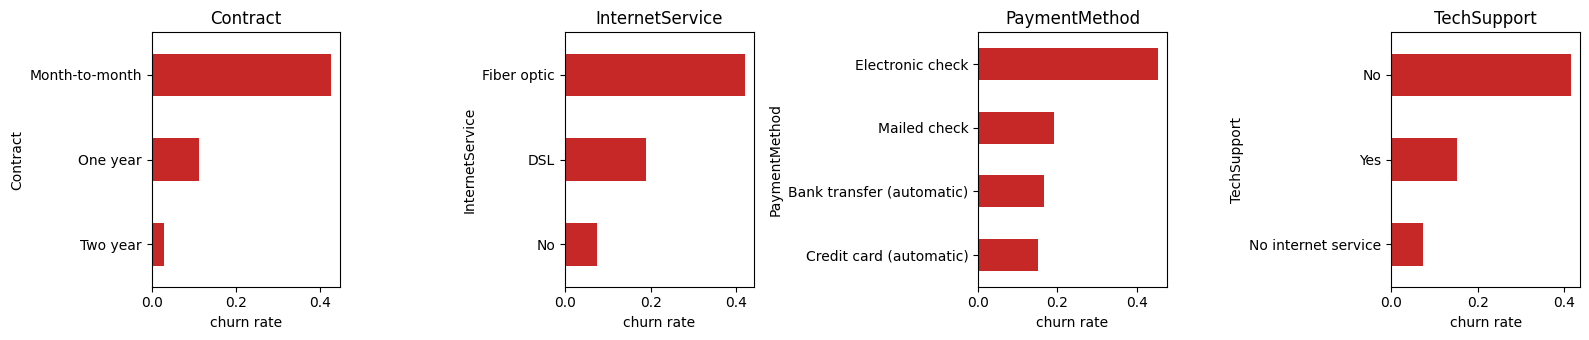

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, (col, t) in zip(axes, tables.items()):
    t["churn_rate"].plot.barh(ax=ax, color="#c62828")
    ax.set_title(col); ax.set_xlabel("churn rate"); ax.invert_yaxis()
plt.tight_layout()

**Observations** (associations, not causes):

- Month-to-month contracts churn far more often than one- or two-year contracts.
- Fiber-optic customers churn more than DSL; customers with no internet churn least.
- Electronic-check payers show the highest churn rate among payment methods.
- Customers without tech support churn more than those with it.

These motivate the engineered features `is_month_to_month` and `has_support` and the simulated
drift scenarios (contract mix, payment channel).

## 5. Leakage review

| Column | Known at scoring time? | Decision |
|---|---|---|
| `customerID` | yes, but an identifier | **dropped** from features (kept for tracing) |
| `tenure`, charges, services, contract, billing | yes — account snapshot | used |
| `Churn` | no — the label | target only |

No column describes a post-churn outcome (e.g. cancellation date or exit survey), so no field was removed
for leakage beyond the ID. `TotalCharges` is strongly correlated with tenure but is a legitimate
snapshot attribute.

In [8]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].corr().round(2)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


## 6. Split plan
No time axis → stratified random 70/15/15 split with `random_state=42` (`src/data/split.py`). All preprocessing is fit on train only, inside the pipeline.